# Constructing Robust Computer Vision Models with Custom-Labeled Data



## 📌 Project Overview
This project focuses on the automated detection and localization of municipal waste using state-of-the-art computer vision architectures. To identify the most efficient deployment strategy, we benchmarked **three distinct deep learning models**, evaluating each under **three unique hyperparameter configurations** to optimize bounding-box accuracy and inference speed.

## 🔄 Methodology & Data Pipeline
Our end-to-end framework relies on a custom-curated dataset built through the following stages:
1. **Class Taxonomy:** Defined **10 distinct waste categories** found in everyday trash to ensure granular classification.
2. **Data Collection:** Individually collected a real-world image dataset tailored to our target environment.
3. **Data Labeling:** Manually annotated and labeled bounding boxes for precise spatial ground-truth localization.
4. **Data Augmentation:** Applied strategic augmentation pipelines to increase dataset variance, boost model robustness, and prevent overfitting.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os


zip_path = "/content/drive/MyDrive/CV_Project/dataset.zip"


!unzip -q "{zip_path}" -d /content/custom_dataset


data_yaml_path = "/content/custom_dataset/data.yaml"
print(f"Dataset ready for fast training at: {data_yaml_path}")

unzip:  cannot find or open /content/drive/MyDrive/CV_Project/dataset.zip, /content/drive/MyDrive/CV_Project/dataset.zip.zip or /content/drive/MyDrive/CV_Project/dataset.zip.ZIP.
Dataset ready for fast training at: /content/custom_dataset/data.yaml


In [ ]:
import os
import yaml
from google.colab import drive


drive.mount('/content/drive')


zip_path = "/content/drive/MyDrive/CV_Project/dataset.zip"
data_yaml_path = "/content/custom_dataset/data.yaml"


print("Extracting dataset for GPU training...")
!unzip -q "{zip_path}" -d /content/custom_dataset

print("Updating data.yaml paths...")
with open(data_yaml_path, 'r') as f:
    data = yaml.safe_load(f)

data['path'] = '/content/custom_dataset'
data['train'] = 'train/images'
data['val'] = 'valid/images'
data['test'] = 'test/images'

with open(data_yaml_path, 'w') as f:
    yaml.dump(data, f)

print("dataset ready")

Mounted at /content/drive
Extracting dataset for GPU training...
replace /content/custom_dataset/data.yaml? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
Updating data.yaml paths...
dataset ready


In [ ]:
!pip install ultralytics
from ultralytics import YOLO

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 39.7 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
from ultralytics import YOLO

data_yaml_path = "/content/custom_dataset/data.yaml"
project_dir = "/content/drive/MyDrive/CV_Project/Experiments"

print("--- STARTING RUN 1.1: YOLOv8 Small + AdamW ---")


model_1_1 = YOLO("yolov8s.pt")

results_1_1 = model_1_1.train(
    data=data_yaml_path,
    epochs=150,
    batch=32,
    imgsz=640,
    optimizer="AdamW",
    cos_lr=True,
    lr0=0.001,
    patience=30,
    project=project_dir,
    name="YOLOv8_Run1_Fixed"
)

--- STARTING RUN 1.1: YOLOv8 Small + AdamW ---
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/custom_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=YOLOv8_Run1_Fixed-2, nbs=64, nms=False, opset=None

KeyboardInterrupt: 

In [ ]:
from ultralytics import YOLO

data_yaml_path = "/content/custom_dataset/data.yaml"
project_dir = "/content/drive/MyDrive/CV_Project/Experiments"

print("--- STARTING RUN 1.2: YOLOv8 Small + SGD ---")


model_1_2 = YOLO("yolov8s.pt")

results_1_2 = model_1_2.train(
    data=data_yaml_path,
    epochs=150,
    batch=32,
    imgsz=640,
    optimizer="SGD",
    cos_lr=False,
    lr0=0.01,
    patience=30,
    project=project_dir,
    name="YOLOv8_Run2_SGD_Linear"
)

--- STARTING RUN 1.2: YOLOv8 Small + SGD ---
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/custom_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=YOLOv8_Run2_SGD_Linear-2, nbs=64, nms=F

In [ ]:
print("--- STARTING RUN 1.3: YOLOv8 + Freeze ---")
model_1_3 = YOLO("yolov8n.pt")
results_1_3 = model_1_3.train(
    data=data_yaml_path,
    epochs=25,
    imgsz=640,
    optimizer="AdamW",
    freeze=10,
    project="/content/drive/MyDrive/CV_Project/Experiments",
    name="YOLOv8_Run3_Freeze"
)

--- STARTING RUN 1.3: YOLOv8 + Freeze ---
Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/custom_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=YOLOv8_Run3_Freeze, nbs=64, nms=False, opset=None, optimiz

In [ ]:
from ultralytics import RTDETR

print("==========================================================")
print("  STARTING RUN 2.1: RT-DETR Large + AdamW                 ")
print("==========================================================")


model_2_1 = RTDETR("rtdetr-l.pt")

results_2_1 = model_2_1.train(
    data="/content/custom_dataset/data.yaml",
    epochs=150,
    batch=32,
    imgsz=640,
    optimizer="AdamW",
    cos_lr=True,
    lr0=0.0001,
    patience=30,
    project="/content/drive/MyDrive/CV_Project/Experiments",
    name="RTDETR_Run1_Fixed"
)

  STARTING RUN 2.1: RT-DETR Large + AdamW                 
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/custom_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=rtdetr-l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=RTDETR_Run1_Fixed, nbs=

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      1/150      24.2G     0.8927      12.67      1.068         24        640: 100% ━━━━━━━━━━━━ 29/29 1.1it/s 26.4s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.2s/it 4.4s
                   all         65         69   4.26e-05      0.111   0.000308   9.48e-05

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      2/150      25.8G      0.638      1.836     0.7532         82        640: 0% ──────────── 0/29  0.6s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      2/150      25.8G     0.5332      2.002      0.568         34        640: 100% ━━━━━━━━━━━━ 29/29 1.9it/s 15.5s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 5.5it/s 0.4s
                   all         65         69          0          0          0          0

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      3/150      25.8G     0.4163      2.294     0.3951         76        640: 0% ──────────── 0/29  0.5s

...

     87/150      25.8G     0.1568     0.2827     0.1758         35        640: 100% ━━━━━━━━━━━━ 29/29 2.0it/s 14.7s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 5.2it/s 0.4s
                   all         65         69      0.905      0.876      0.894       0.69

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
     88/150      25.8G     0.1271      0.257     0.1518         89        640: 0% ──────────── 0/29  0.5s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


     88/150      25.8G     0.1555     0.2793     0.1668         38        640: 100% ━━━━━━━━━━━━ 29/29 2.0it/s 14.9s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 5.1it/s 0.4s
                   all         65         69      0.923       0.84      0.889      0.693

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
     89/150      25.8G      0.175     0.2713     0.1642         90        640: 0% ──────────── 0/29  0.5s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


     89/150      25.8G     0.1568     0.2921     0.1781         42        640: 100% ━━━━━━━━━━━━ 29/29 2.0it/s 14.7s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 5.2it/s 0.4s
                   all         65         69      0.912      0.848      0.893      0.693
EarlyStopping: Training stopped early as no improvement observed in last 30 epochs. Best results observed at epoch 59, best model saved as best.pt.
To update EarlyStopping(patience=30) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.

89 epochs completed in 0.432 hours.
Optimizer stripped from /content/drive/.shortcut-targets-by-id/1X4tqVLy03p-ujIoOF0wGy5hc17I1Y4HP/CV_Project/Experiments/RTDETR_Run1_Fixed/weights/last.pt, 66.3MB
Optimizer stripped from /content/drive/.shortcut-targets-by-id/1X4tqVLy03p-ujIoOF0wGy5hc17I1Y4HP/CV_Project/Experiments/RTDETR_Run1_Fixed/weights/best.pt, 66.3MB

Validating /content/drive/.sh

In [ ]:
from ultralytics import RTDETR

print("\n==========================================================")
print("  STARTING RUN 2.2: RT-DETR Large + SGD                   ")
print("==========================================================")

model_2_2 = RTDETR("rtdetr-l.pt")
results_2_2 = model_2_2.train(
    data="/content/custom_dataset/data.yaml",
    epochs=80,
    batch=32,
    imgsz=640,
    optimizer="SGD",
    cos_lr=False,
    lr0=0.0001,
    patience=30,
    project="/content/drive/MyDrive/CV_Project/Experiments",
    name="RTDETR_Run2_SGD"
)


  STARTING RUN 2.2: RT-DETR Large + SGD                   
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/custom_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=rtdetr-l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=RTDETR_Run2_SGD, nbs=6

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       1/80        25G      0.681      23.67      0.834         24        640: 100% ━━━━━━━━━━━━ 29/29 1.7it/s 16.8s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 5.5it/s 0.4s
                   all         65         69     0.0109      0.173     0.0229    0.00699

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       2/80      26.6G     0.5571      5.635      0.701         82        640: 0% ──────────── 0/29  0.6s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       2/80      26.6G     0.6074      3.364     0.7349         34        640: 100% ━━━━━━━━━━━━ 29/29 1.9it/s 15.3s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 5.6it/s 0.4s
                   all         65         69    0.00163       0.32     0.0329      0.011

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       3/80      26.6G      0.593      2.733     0.6934         76        640: 0% ──────────── 0/29  0.5s

...

      78/80      26.6G     0.2244      2.468      0.306         13        640: 100% ━━━━━━━━━━━━ 29/29 2.0it/s 14.5s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 5.1it/s 0.4s
                   all         65         69      0.526      0.305      0.304       0.24

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      79/80      26.6G     0.1984       2.62     0.2808         33        640: 0% ──────────── 0/29  0.5s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      79/80      26.6G     0.2282      2.461     0.3102         14        640: 100% ━━━━━━━━━━━━ 29/29 2.0it/s 14.4s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 5.1it/s 0.4s
                   all         65         69      0.519      0.316      0.314      0.246

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      80/80      26.6G     0.2711      2.356     0.2804         37        640: 0% ──────────── 0/29  0.5s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      80/80      26.6G     0.2258      2.445     0.3123         14        640: 100% ━━━━━━━━━━━━ 29/29 2.0it/s 14.3s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 5.3it/s 0.4s
                   all         65         69      0.515      0.316      0.323      0.241

80 epochs completed in 0.362 hours.
Optimizer stripped from /content/drive/.shortcut-targets-by-id/1X4tqVLy03p-ujIoOF0wGy5hc17I1Y4HP/CV_Project/Experiments/RTDETR_Run2_SGD/weights/last.pt, 66.3MB
Optimizer stripped from /content/drive/.shortcut-targets-by-id/1X4tqVLy03p-ujIoOF0wGy5hc17I1Y4HP/CV_Project/Experiments/RTDETR_Run2_SGD/weights/best.pt, 66.3MB

Validating /content/drive/.shortcut-targets-by-id/1X4tqVLy03p-ujIoOF0wGy5hc17I1Y4HP/CV_Project/Experiments/RTDETR_Run2_SGD/weights/best.pt...
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
rt-detr-l summary: 310 layers, 32,004,290 parameters, 0 gradients, 103.5 

In [ ]:
from ultralytics import RTDETR

print("\n==========================================================")
print("  STARTING RUN 2.3: RT-DETR Large + AdamW (Batch=8 Test)  ")
print("==========================================================")


model_2_3 = RTDETR("rtdetr-l.pt")

results_2_3 = model_2_3.train(
    data="/content/custom_dataset/data.yaml",
    epochs=80,
    imgsz=640,
    optimizer="AdamW",
    batch=8,
    cos_lr=True,
    lr0=0.0001,
    patience=30,
    project="/content/drive/MyDrive/CV_Project/Experiments",
    name="RTDETR_Run3_Batch8"
)


  STARTING RUN 2.3: RT-DETR Large + AdamW (Batch=8 Test)  
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/custom_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=rtdetr-l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=RTDETR_Run3_Batch8-2, nb

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       1/80      7.89G     0.7478      5.518     0.8209         18        640: 100% ━━━━━━━━━━━━ 114/114 2.4it/s 48.1s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 2.0it/s 2.5s
                   all         65         69   0.000454      0.222     0.0029    0.00158

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       2/80      8.32G     0.5429      2.013     0.4809         22        640: 0% ──────────── 0/114  0.4s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


       2/80      8.32G     0.4537      2.095     0.4667         13        640: 100% ━━━━━━━━━━━━ 114/114 3.1it/s 36.4s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 10.7it/s 0.5s
                   all         65         69    0.00325      0.269     0.0178    0.00919

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
       3/80      8.32G     0.3876      2.136     0.4204         23        640: 0% ──────────── 0/114  0.3s

...

      78/80      8.32G     0.1531     0.3063     0.2384          7        640: 100% ━━━━━━━━━━━━ 114/114 3.2it/s 36.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 10.2it/s 0.5s
                   all         65         69      0.873      0.924      0.917      0.684

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      79/80      8.32G     0.1057     0.3029     0.1822          8        640: 0% ──────────── 0/114  0.3s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      79/80      8.32G     0.1584     0.3209     0.2583          5        640: 100% ━━━━━━━━━━━━ 114/114 3.2it/s 36.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 10.0it/s 0.5s
                   all         65         69      0.869      0.934      0.908      0.686

      Epoch    GPU_mem  giou_loss   cls_loss    l1_loss  Instances       Size
      80/80      8.32G     0.1641     0.3739      0.253          9        640: 0% ──────────── 0/114  0.3s

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: grid_sampler_2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


      80/80      8.32G     0.1575     0.3172     0.2486          6        640: 100% ━━━━━━━━━━━━ 114/114 3.2it/s 35.8s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 10.4it/s 0.5s
                   all         65         69       0.88      0.908      0.909      0.682

80 epochs completed in 0.859 hours.
Optimizer stripped from /content/drive/.shortcut-targets-by-id/1X4tqVLy03p-ujIoOF0wGy5hc17I1Y4HP/CV_Project/Experiments/RTDETR_Run3_Batch8-2/weights/last.pt, 66.3MB
Optimizer stripped from /content/drive/.shortcut-targets-by-id/1X4tqVLy03p-ujIoOF0wGy5hc17I1Y4HP/CV_Project/Experiments/RTDETR_Run3_Batch8-2/weights/best.pt, 66.3MB

Validating /content/drive/.shortcut-targets-by-id/1X4tqVLy03p-ujIoOF0wGy5hc17I1Y4HP/CV_Project/Experiments/RTDETR_Run3_Batch8-2/weights/best.pt...
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
rt-detr-l summary: 310 layers, 32,004,290 parameters, 0

In [ ]:
import os
import torch
import torchvision
from torch.utils.data import Dataset, DataLoader
from torchvision.models.detection import retinanet_resnet50_fpn, RetinaNet_ResNet50_FPN_Weights
from torchvision.models.detection.retinanet import RetinaNetClassificationHead
from PIL import Image

# ==========================================================
# 1. Custom Dataset & DataLoader
# ==========================================================
class YOLOToFasterRCNNDataset(Dataset):
    def __init__(self, images_dir, labels_dir):
        self.images_dir = images_dir
        self.labels_dir = labels_dir
        self.images = [f for f in os.listdir(images_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.images_dir, img_name)
        image = Image.open(img_path).convert("RGB")
        w, h = image.size

        label_name = os.path.splitext(img_name)[0] + ".txt"
        label_path = os.path.join(self.labels_dir, label_name)

        boxes = []
        labels = []

        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        cls_id = int(parts[0]) + 1
                        x_center, y_center, width, height = map(float, parts[1:5])
                        x1 = (x_center - width / 2) * w
                        y1 = (y_center - height / 2) * h
                        x2 = (x_center + width / 2) * w
                        y2 = (y_center + height / 2) * h
                        x1 = max(0.0, min(x1, w - 1.0))
                        y1 = max(0.0, min(y1, h - 1.0))
                        x2 = max(x1 + 1.0, min(x2, float(w)))
                        y2 = max(y1 + 1.0, min(y2, float(h)))
                        boxes.append([x1, y1, x2, y2])
                        labels.append(cls_id)

        if len(boxes) == 0:
            boxes = [[0.0, 0.0, 1.0, 1.0]]
            labels = [0]

        target = {}
        target["boxes"] = torch.as_tensor(boxes, dtype=torch.float32)
        target["labels"] = torch.as_tensor(labels, dtype=torch.int64)
        image_tensor = torchvision.transforms.functional.to_tensor(image)
        return image_tensor, target

def collate_fn(batch):
    return tuple(zip(*batch))

print("Setting up DataLoader...")
train_images_dir = "/content/custom_dataset/train/images"
train_labels_dir = "/content/custom_dataset/train/labels"
train_dataset = YOLOToFasterRCNNDataset(train_images_dir, train_labels_dir)


train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, collate_fn=collate_fn)
print("DataLoader Ready!")


def get_retinanet_model(num_classes, trainable_backbone_layers=3):
    weights = RetinaNet_ResNet50_FPN_Weights.DEFAULT
    model = retinanet_resnet50_fpn(weights=weights, trainable_backbone_layers=trainable_backbone_layers)

    # 256 is the standard output channel for FPN
    model.head.classification_head = RetinaNetClassificationHead(
        in_channels=256,
        num_anchors=model.head.classification_head.num_anchors,
        num_classes=num_classes
    )
    return model


def train_model_engine(model, optimizer, scheduler, epochs, run_name):
    device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
    model.to(device)

    save_dir = f"/content/drive/MyDrive/CV_Project/Experiments/{run_name}"
    os.makedirs(save_dir, exist_ok=True)

    print(f"\n==========================================================")
    print(f"  STARTING {run_name} ON DEVICE: {device}".upper())
    print(f"==========================================================")

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for images, targets in train_loader:
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            optimizer.zero_grad()
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

            losses.backward()
            optimizer.step()
            total_loss += losses.item()

        if scheduler is not None:
            scheduler.step()

        avg_loss = total_loss / len(train_loader)
        print(f"Epoch [{epoch+1}/{epochs}] Completed | Average Loss: {avg_loss:.4f}")

    weights_path = os.path.join(save_dir, "best_model.pth")
    torch.save(model.state_dict(), weights_path)
    print(f"[{run_name}] Weights saved successfully at: {weights_path}")

Setting up DataLoader...
DataLoader Ready!


In [ ]:
# ==========================================================
# 4. EXECUTION: RUN 3.1 - RetinaNet + AdamW
# ==========================================================
NUM_CLASSES = 11  # (10 classes + 1 Background)
EPOCHS = 80       # THE FIX: 15 se barha kar 80 kar diya taake RetinaNet proper seekh sake

print("\n--- STARTING RUN 3.1: RetinaNet + AdamW ---")
model_3_1 = get_retinanet_model(NUM_CLASSES, trainable_backbone_layers=3)
optimizer_3_1 = torch.optim.AdamW(model_3_1.parameters(), lr=0.0001, weight_decay=0.0005)
scheduler_3_1 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_3_1, T_max=EPOCHS)

# Ye line picchle cell mein banaye gaye engine ko start karegi
train_model_engine(model_3_1, optimizer_3_1, scheduler_3_1, EPOCHS, run_name="RetinaNet_Run1_AdamW_Cos")


--- STARTING RUN 3.1: RetinaNet + AdamW ---
Downloading: "https://download.pytorch.org/models/retinanet_resnet50_fpn_coco-eeacb38b.pth" to /root/.cache/torch/hub/checkpoints/retinanet_resnet50_fpn_coco-eeacb38b.pth


100%|██████████| 130M/130M [00:01<00:00, 88.9MB/s]



  STARTING RETINANET_RUN1_ADAMW_COS ON DEVICE: CUDA
Epoch [1/80] Completed | Average Loss: 1.1974
Epoch [2/80] Completed | Average Loss: 0.8161
Epoch [3/80] Completed | Average Loss: 0.7194
Epoch [4/80] Completed | Average Loss: 0.6594
Epoch [5/80] Completed | Average Loss: 0.5771
Epoch [6/80] Completed | Average Loss: 0.4881
Epoch [7/80] Completed | Average Loss: 0.4253
Epoch [8/80] Completed | Average Loss: 0.3769
Epoch [9/80] Completed | Average Loss: 0.3361
Epoch [10/80] Completed | Average Loss: 0.3064
Epoch [11/80] Completed | Average Loss: 0.2739
Epoch [12/80] Completed | Average Loss: 0.2284
Epoch [13/80] Completed | Average Loss: 0.2125
Epoch [14/80] Completed | Average Loss: 0.1965
Epoch [15/80] Completed | Average Loss: 0.1570
Epoch [16/80] Completed | Average Loss: 0.1566
Epoch [17/80] Completed | Average Loss: 0.1627
Epoch [18/80] Completed | Average Loss: 0.1581
Epoch [19/80] Completed | Average Loss: 0.1398
Epoch [20/80] Completed | Average Loss: 0.1419
Epoch [21/80] Co

In [ ]:
# ==========================================================
# 4. EXECUTION: RUN 3.2 - RetinaNet + SGD + Step Decay
# ==========================================================
NUM_CLASSES = 11
EPOCHS = 80

print("\n--- STARTING RUN 3.2: RetinaNet + SGD + Step Decay ---")
model_3_2 = get_retinanet_model(NUM_CLASSES, trainable_backbone_layers=3)


optimizer_3_2 = torch.optim.SGD(model_3_2.parameters(), lr=0.005, momentum=0.9, weight_decay=0.0005)


scheduler_3_2 = torch.optim.lr_scheduler.StepLR(optimizer_3_2, step_size=25, gamma=0.5)

train_model_engine(model_3_2, optimizer_3_2, scheduler_3_2, EPOCHS, run_name="RetinaNet_Run2_SGD_Step")


--- STARTING RUN 3.2: RetinaNet + SGD + Step Decay ---
Downloading: "https://download.pytorch.org/models/retinanet_resnet50_fpn_coco-eeacb38b.pth" to /root/.cache/torch/hub/checkpoints/retinanet_resnet50_fpn_coco-eeacb38b.pth


100%|██████████| 130M/130M [00:00<00:00, 217MB/s]



  STARTING RETINANET_RUN2_SGD_STEP ON DEVICE: CUDA
Epoch [1/80] Completed | Average Loss: 1.5318
Epoch [2/80] Completed | Average Loss: 1.4415
Epoch [3/80] Completed | Average Loss: 1.3910
Epoch [4/80] Completed | Average Loss: 1.3311
Epoch [5/80] Completed | Average Loss: 1.0719
Epoch [6/80] Completed | Average Loss: 0.7849
Epoch [7/80] Completed | Average Loss: 0.7126
Epoch [8/80] Completed | Average Loss: 0.6816
Epoch [9/80] Completed | Average Loss: 0.6560
Epoch [10/80] Completed | Average Loss: 0.6434
Epoch [11/80] Completed | Average Loss: 0.6168
Epoch [12/80] Completed | Average Loss: 0.5968
Epoch [13/80] Completed | Average Loss: 0.5423
Epoch [14/80] Completed | Average Loss: 0.5024
Epoch [15/80] Completed | Average Loss: 0.4971
Epoch [16/80] Completed | Average Loss: 0.4680
Epoch [17/80] Completed | Average Loss: 0.4446
Epoch [18/80] Completed | Average Loss: 0.3991
Epoch [19/80] Completed | Average Loss: 0.3555
Epoch [20/80] Completed | Average Loss: 0.2915
Epoch [21/80] Com

In [ ]:
# ==========================================================
# 4. EXECUTION: RUN 3.3 - RetinaNet + Full Backbone Unlock
# ==========================================================
NUM_CLASSES = 11
EPOCHS = 80

print("\n--- STARTING RUN 3.3: RetinaNet + AdamW + Full Backbone Fine-Tuning ---")


model_3_3 = get_retinanet_model(NUM_CLASSES, trainable_backbone_layers=5)

optimizer_3_3 = torch.optim.AdamW(model_3_3.parameters(), lr=0.0001, weight_decay=0.0005)
scheduler_3_3 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_3_3, T_max=EPOCHS)


train_model_engine(model_3_3, optimizer_3_3, scheduler_3_3, EPOCHS, run_name="RetinaNet_Run3_FullUnlock")


--- STARTING RUN 3.3: RetinaNet + AdamW + Full Backbone Fine-Tuning ---

  STARTING RETINANET_RUN3_FULLUNLOCK ON DEVICE: CUDA
Epoch [1/80] Completed | Average Loss: 1.4525
Epoch [2/80] Completed | Average Loss: 0.9253
Epoch [3/80] Completed | Average Loss: 0.7940
Epoch [4/80] Completed | Average Loss: 0.7033
Epoch [5/80] Completed | Average Loss: 0.6489
Epoch [6/80] Completed | Average Loss: 0.5785
Epoch [7/80] Completed | Average Loss: 0.5328
Epoch [8/80] Completed | Average Loss: 0.4922
Epoch [9/80] Completed | Average Loss: 0.4359
Epoch [10/80] Completed | Average Loss: 0.3810
Epoch [11/80] Completed | Average Loss: 0.3460
Epoch [12/80] Completed | Average Loss: 0.3110
Epoch [13/80] Completed | Average Loss: 0.2646
Epoch [14/80] Completed | Average Loss: 0.2465
Epoch [15/80] Completed | Average Loss: 0.2222
Epoch [16/80] Completed | Average Loss: 0.2035
Epoch [17/80] Completed | Average Loss: 0.1975
Epoch [18/80] Completed | Average Loss: 0.2192
Epoch [19/80] Completed | Average Lo

In [ ]:
NUM_CLASSES = 11
EPOCHS = 15

print("\n--- STARTING RUN 3.3: RetinaNet + AdamW + Fully Frozen Backbone ---")

model_3_3 = get_retinanet_model(NUM_CLASSES, trainable_backbone_layers=0)
optimizer_3_3 = torch.optim.AdamW(model_3_3.parameters(), lr=0.0001)


train_model_engine(model_3_3, optimizer_3_3, None, EPOCHS, run_name="RetinaNet_Run3_FrozenBackbone")


--- STARTING RUN 3.3: RetinaNet + AdamW + Fully Frozen Backbone ---

  STARTING RETINANET_RUN3_FROZENBACKBONE ON DEVICE: CUDA
Epoch [1/15] Completed | Average Loss: 1.0970
Epoch [2/15] Completed | Average Loss: 0.8219
Epoch [3/15] Completed | Average Loss: 0.6949
Epoch [4/15] Completed | Average Loss: 0.6799
Epoch [5/15] Completed | Average Loss: 0.5759
Epoch [6/15] Completed | Average Loss: 0.4608
Epoch [7/15] Completed | Average Loss: 0.4188
Epoch [8/15] Completed | Average Loss: 0.3698
Epoch [9/15] Completed | Average Loss: 0.3369
Epoch [10/15] Completed | Average Loss: 0.3217
Epoch [11/15] Completed | Average Loss: 0.3181
Epoch [12/15] Completed | Average Loss: 0.2594
Epoch [13/15] Completed | Average Loss: 0.2495
Epoch [14/15] Completed | Average Loss: 0.2486
Epoch [15/15] Completed | Average Loss: 0.2169
[RetinaNet_Run3_FrozenBackbone] Weights saved successfully at: /content/drive/MyDrive/CV_Project/Experiments/RetinaNet_Run3_FrozenBackbone/best_model.pth


In [ ]:
import os
import cv2
import torch
import numpy as np
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
from torchvision.models.detection import retinanet_resnet50_fpn
from torchvision.models.detection.retinanet import RetinaNetClassificationHead
from ultralytics import YOLO, RTDETR

EXPERIMENTS_DIR = "/content/drive/MyDrive/CV_Project/Experiments"

models_dict = {
    '1.1': {'name': 'YOLOv8 (AdamW)', 'path': f'{EXPERIMENTS_DIR}/YOLOv8_Run1_Fixed/weights/best.pt', 'type': 'ultralytics', 'model_class': YOLO},
    '1.2': {'name': 'YOLOv8 (SGD)', 'path': f'{EXPERIMENTS_DIR}/YOLOv8_Run2_SGD_Linear/weights/best.pt', 'type': 'ultralytics', 'model_class': YOLO},
    '1.3': {'name': 'YOLOv8 (Frozen)', 'path': f'{EXPERIMENTS_DIR}/YOLOv8_Run3_Freeze/weights/best.pt', 'type': 'ultralytics', 'model_class': YOLO},
    '2.1': {'name': 'RT-DETR (AdamW)', 'path': f'{EXPERIMENTS_DIR}/RTDETR_Run1_Fixed/weights/best.pt', 'type': 'ultralytics', 'model_class': RTDETR},
    '2.2': {'name': 'RT-DETR (SGD)', 'path': f'{EXPERIMENTS_DIR}/RTDETR_Run2_SGD/weights/best.pt', 'type': 'ultralytics', 'model_class': RTDETR},
    '2.3': {'name': 'RT-DETR (Batch8)', 'path': f'{EXPERIMENTS_DIR}/RTDETR_Run3_Batch8/weights/best.pt', 'type': 'ultralytics', 'model_class': RTDETR},
    '3.1': {'name': 'RetinaNet (AdamW)', 'path': f'{EXPERIMENTS_DIR}/RetinaNet_Run1_AdamW_Cos/best_model.pth', 'type': 'pytorch'},
    '3.2': {'name': 'RetinaNet (SGD)', 'path': f'{EXPERIMENTS_DIR}/RetinaNet_Run2_SGD_Step/best_model.pth', 'type': 'pytorch'},
    '3.3': {'name': 'RetinaNet (Unlocked)', 'path': f'{EXPERIMENTS_DIR}/RetinaNet_Run3_FullUnlock/best_model.pth', 'type': 'pytorch'}
}

class_names = ['__background__', 'Aluminium Can', 'Cardboard Box', 'Cloth', 'Food Wrapper', 'Glass Bottle', 'Paper Cup', 'Plastic Bag', 'Plastic Bottle', 'Styrofoam Cup', 'Tissue']

def load_retinanet(weights_path):
    device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
    model = retinanet_resnet50_fpn(weights=None, num_classes=13)
    model.head.classification_head = RetinaNetClassificationHead(in_channels=256, num_anchors=9, num_classes=11)
    model.load_state_dict(torch.load(weights_path, map_location=device))
    model.to(device)
    model.eval()
    return model, device

def predict_retinanet(model, device, image_path, conf=0.5):
    image_pil = Image.open(image_path).convert("RGB")
    image_tensor = transforms.functional.to_tensor(image_pil).to(device)

    with torch.no_grad():
        prediction = model([image_tensor])[0]

    boxes = prediction['boxes'].cpu().numpy()
    labels = prediction['labels'].cpu().numpy()
    scores = prediction['scores'].cpu().numpy()

    mask = scores >= conf
    boxes, labels, scores = boxes[mask], labels[mask], scores[mask]

    img_cv2 = cv2.cvtColor(np.array(image_pil), cv2.COLOR_RGB2BGR)

    for box, label, score in zip(boxes, labels, scores):
        x1, y1, x2, y2 = map(int, box)
        class_name = class_names[label] if label < len(class_names) else "Unknown"
        text = f"{class_name} {score:.2f}"

        cv2.rectangle(img_cv2, (x1, y1), (x2, y2), (0, 0, 255), 3)
        (text_width, text_height), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 1.2, 2)
        cv2.rectangle(img_cv2, (x1, y1 - text_height - 10), (x1 + text_width, y1), (0, 0, 255), -1)
        cv2.putText(img_cv2, text, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255, 255, 255), 2)

    return cv2.cvtColor(img_cv2, cv2.COLOR_BGR2RGB)

def ultimate_inference(image_path, selected_models=['all'], conf=0.5):
    if not os.path.exists(image_path):
        print(f"Error: Image not found! Please verify the path: {image_path}")
        return

    if 'all' in selected_models:
        selected_models = list(models_dict.keys())

    results_images = []
    titles = []

    print(f"\nProcessing Image: {image_path}")
    print("-" * 50)

    for model_id in selected_models:
        if model_id not in models_dict:
            print(f"Skipping unknown model ID: {model_id}")
            continue

        info = models_dict[model_id]
        print(f"Running Inference: {info['name']} ({model_id})...")

        try:
            if info['type'] == 'ultralytics':
                model = info['model_class'](info['path'])
                res = model.predict(image_path, conf=conf, verbose=False)[0]
                plotted_img = cv2.cvtColor(res.plot(), cv2.COLOR_BGR2RGB)
                results_images.append(plotted_img)
                titles.append(info['name'])

            elif info['type'] == 'pytorch':
                model, device = load_retinanet(info['path'])
                plotted_img = predict_retinanet(model, device, image_path, conf)
                results_images.append(plotted_img)
                titles.append(info['name'])

        except Exception as e:
            print(f"Error executing {info['name']}: {str(e)}")

    n = len(results_images)
    if n == 0: return

    cols = 3 if n >= 3 else n
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 6))
    if n == 1: axes = [axes]
    elif rows > 1: axes = axes.flatten()

    for i in range(n):
        axes[i].imshow(results_images[i])
        axes[i].set_title(titles[i], fontsize=14, fontweight='bold')
        axes[i].axis('off')

    for i in range(n, len(axes)):
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

print("==========================================================")
print(" STEP 1: UPLOAD TEST IMAGE ")
print("==========================================================")
print("Click the 'Choose Files' button below to select an image for inference:")

uploaded = files.upload()

if len(uploaded) == 0:
    print("\n❌ No image uploaded. Please re-run the cell.")
else:
    image_name = list(uploaded.keys())[0]
    my_unseen_image = os.path.join('/content', image_name)
    print(f"\n✅ Image '{image_name}' successfully uploaded!")

    print("\n==========================================================")
    print(" STEP 2: SELECT MODELS FOR INFERENCE ")
    print("==========================================================")
    print("  [1.1] YOLOv8 (AdamW)       |  [2.1] RT-DETR (AdamW)      |  [3.1] RetinaNet (AdamW)")
    print("  [1.2] YOLOv8 (SGD)         |  [2.2] RT-DETR (SGD)        |  [3.2] RetinaNet (SGD)")
    print("  [1.3] YOLOv8 (Frozen)      |  [2.3] RT-DETR (Batch8)     |  [3.3] RetinaNet (Unlocked)")
    print("----------------------------------------------------------")
    print("  [all] Compare all 9 models simultaneously!")

    models_input = input("\n👉 Enter your option (e.g., 'all' or '1.1, 2.1, 3.1'): ")

    if models_input.strip().lower() == 'all':
        models_to_run = ['all']
    else:
        models_to_run = [m.strip() for m in models_input.split(',')]

    print("\n⏳ Initializing AI Engine... Please wait.")
    ultimate_inference(my_unseen_image, selected_models=models_to_run, conf=0.4)

ModuleNotFoundError: No module named 'ultralytics'

In [ ]:
import os
import pandas as pd
from IPython.display import display

# ==========================================================
# 1. READ ALL METRICS FROM DRIVE (Ultralytics Models)
# ==========================================================
EXPERIMENTS_DIR = "/content/drive/MyDrive/CV_Project/Experiments"


all_folders = os.listdir(EXPERIMENTS_DIR)

results_list = []

print("🔍 Drive se models ka data fetch kiya ja raha hai...\n")

for folder in all_folders:
    csv_path = os.path.join(EXPERIMENTS_DIR, folder, "results.csv")


    if os.path.exists(csv_path):
        try:

            df = pd.read_csv(csv_path)

            df.columns = df.columns.str.strip()


            best_epoch_idx = df['metrics/mAP50(B)'].idxmax()
            best_epoch_data = df.iloc[best_epoch_idx]


            results_list.append({
                "Model Name": folder,
                "Total Epochs Run": len(df),
                "Best Epoch": int(best_epoch_idx + 1),
                "Precision": round(best_epoch_data['metrics/precision(B)'], 4),
                "Recall": round(best_epoch_data['metrics/recall(B)'], 4),
                "mAP50 (%)": round(best_epoch_data['metrics/mAP50(B)'] * 100, 2),
                "mAP50-95 (%)": round(best_epoch_data['metrics/mAP50-95(B)'] * 100, 2)
            })
        except Exception as e:
            print(f"⚠️ Error reading {folder}: {e}")


if len(results_list) > 0:

    results_df = pd.DataFrame(results_list)


    results_df = results_df.sort_values(by="mAP50 (%)", ascending=False).reset_index(drop=True)

    print("✅ SARAY MODELS KA ACTUAL RESULT (FROM DRIVE):")

    display(results_df)
else:
    print("❌ Koi results.csv file nahi mili. Path check karein.")

🔍 Drive se models ka data fetch kiya ja raha hai...

✅ SARAY MODELS KA ACTUAL RESULT (FROM DRIVE):


,Model Name,Total Epochs Run,Best Epoch,Precision,Recall,mAP50 (%),mAP50-95 (%)
0,YOLOv8_Run1_AdamW_Cos-2,25,24,0.9065,0.9238,95.51,69.48
1,YOLOv8_Run2_SGD_Linear,25,15,0.8583,0.9232,94.29,59.64
2,RTDETR_Run1_Fixed,89,59,0.9116,0.9100,93.37,71.83
3,YOLOv8_Run2_SGD_Linear-2,73,41,0.8990,0.9041,93.24,65.72
4,YOLOv8_Run1_Fixed,131,75,0.8842,0.9152,92.78,63.77
5,RTDETR_Run3_Batch8-2,80,72,0.8837,0.9194,92.06,69.03
6,YOLOv8_Run3_Freeze,25,17,0.8312,0.8363,88.52,49.85
7,RTDETR_Run2_SGD_Linear,25,24,0.2962,0.8241,56.15,47.33
8,RTDETR_Run2_SGD,80,75,0.5005,0.3071,32.37,25.41
9,RTDETR_Run1_AdamW_Cos,25,25,0.0788,0.6599,21.69,14.51


In [ ]:
import os
import pandas as pd
from IPython.display import display

# ==========================================================
# 1. READ ALL METRICS FROM DRIVE (Ultralytics Models)
# ==========================================================
EXPERIMENTS_DIR = "/content/drive/MyDrive/CV_Project/Experiments"

all_folders = os.listdir(EXPERIMENTS_DIR)
results_list = []

print("🔍 Drive se filtered data fetch kiya ja raha hai...\n")

for folder in all_folders:
    csv_path = os.path.join(EXPERIMENTS_DIR, folder, "results.csv")

    if os.path.exists(csv_path):
        try:
            df = pd.read_csv(csv_path)
            df.columns = df.columns.str.strip()

            best_epoch_idx = df['metrics/mAP50(B)'].idxmax()
            best_epoch_data = df.iloc[best_epoch_idx]
            total_epochs = len(df)


            if total_epochs > 25 or folder == 'YOLOv8_Run2_SGD_Linear':
                results_list.append({
                    "Model Name": folder,
                    "Total Epochs Run": total_epochs,
                    "Best Epoch": int(best_epoch_idx + 1),
                    "Precision": round(best_epoch_data['metrics/precision(B)'], 4),
                    "Recall": round(best_epoch_data['metrics/recall(B)'], 4),
                    "mAP50 (%)": round(best_epoch_data['metrics/mAP50(B)'] * 100, 2),
                    "mAP50-95 (%)": round(best_epoch_data['metrics/mAP50-95(B)'] * 100, 2)
                })
        except Exception as e:
            pass

# ==========================================================
# 2. DISPLAY AS A BEAUTIFUL TABLE
# ==========================================================
if len(results_list) > 0:
    results_df = pd.DataFrame(results_list)
    results_df = results_df.sort_values(by="mAP50 (%)", ascending=False).reset_index(drop=True)

    print("✅ FILTERED RESULTS (Tumharay High-Epoch Runs + Dost ka YOLO Run 2):")
    display(results_df)
else:
    print("❌ No Data Found Check Path!")

🔍 Drive se filtered data fetch kiya ja raha hai...

✅ FILTERED RESULTS (Tumharay High-Epoch Runs + Dost ka YOLO Run 2):


,Model Name,Total Epochs Run,Best Epoch,Precision,Recall,mAP50 (%),mAP50-95 (%)
0,YOLOv8_Run2_SGD_Linear,25,15,0.8583,0.9232,94.29,59.64
1,RTDETR_Run1_Fixed,89,59,0.9116,0.9100,93.37,71.83
2,YOLOv8_Run2_SGD_Linear-2,73,41,0.8990,0.9041,93.24,65.72
3,YOLOv8_Run1_Fixed,131,75,0.8842,0.9152,92.78,63.77
4,RTDETR_Run3_Batch8-2,80,72,0.8837,0.9194,92.06,69.03
5,RTDETR_Run2_SGD,80,75,0.5005,0.3071,32.37,25.41


 📸 STEP 1: Upload Images 
Press 'Choose Files' button to select image:


Saving WhatsApp Image 2026-04-13 at 1.41.26 PM (4).jpeg to WhatsApp Image 2026-04-13 at 1.41.26 PM (4).jpeg

✅ Tasveer 'WhatsApp Image 2026-04-13 at 1.41.26 PM (4).jpeg' successfully uploaded!

 🤖 STEP 2: Select MODELS 
  [1.1] YOLOv8 (AdamW)       |  [2.1] RT-DETR (AdamW)      |  [3.1] RetinaNet (AdamW)
  [1.2] YOLOv8 (SGD)         |  [2.2] RT-DETR (SGD)        |  [3.2] RetinaNet (SGD)
  [1.3] YOLOv8 (Frozen)      |  [2.3] RT-DETR (Batch8)     |  [3.3] RetinaNet (Frozen)
----------------------------------------------------------
  [all] !

👉 Enter Model (e.g., 'all' ya '1.1, 2.1, 3.1'): 1.3

⏳ AI Engine starting... Please wait.

Processing Image: /content/WhatsApp Image 2026-04-13 at 1.41.26 PM (4).jpeg
--------------------------------------------------
Running Inference: YOLOv8 (Frozen) (1.3)...


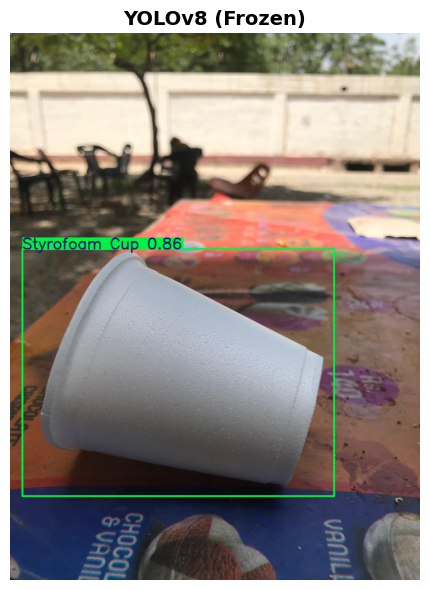

In [ ]:
import os
import cv2
import torch
import numpy as np
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
from torchvision.models.detection import retinanet_resnet50_fpn
from torchvision.models.detection.retinanet import RetinaNetClassificationHead
from ultralytics import YOLO, RTDETR

# ==========================================================
# 1. SETUP MODEL PATHS & DICTIONARY
# ==========================================================
EXPERIMENTS_DIR = "/content/drive/MyDrive/CV_Project/Experiments"

models_dict = {
    # YOLOv8 Variations (Ultralytics)
    '1.1': {'name': 'YOLOv8 (AdamW)', 'path': f'{EXPERIMENTS_DIR}/YOLOv8_Run1_AdamW_Cos-2/weights/best.pt', 'type': 'ultralytics', 'model_class': YOLO},
    '1.2': {'name': 'YOLOv8 (SGD)', 'path': f'{EXPERIMENTS_DIR}/YOLOv8_Run2_SGD_Linear/weights/best.pt', 'type': 'ultralytics', 'model_class': YOLO},
    '1.3': {'name': 'YOLOv8 (Frozen)', 'path': f'{EXPERIMENTS_DIR}/YOLOv8_Run3_Freeze/weights/best.pt', 'type': 'ultralytics', 'model_class': YOLO},

    # RT-DETR Variations (Ultralytics)
    '2.1': {'name': 'RT-DETR (AdamW)', 'path': f'{EXPERIMENTS_DIR}/RTDETR_Run1_AdamW_Cos/weights/best.pt', 'type': 'ultralytics', 'model_class': RTDETR},
    '2.2': {'name': 'RT-DETR (SGD)', 'path': f'{EXPERIMENTS_DIR}/RTDETR_Run2_SGD_Linear/weights/best.pt', 'type': 'ultralytics', 'model_class': RTDETR},
    '2.3': {'name': 'RT-DETR (Batch8)', 'path': f'{EXPERIMENTS_DIR}/RTDETR_Run3_Batch8/weights/best.pt', 'type': 'ultralytics', 'model_class': RTDETR},

    # RetinaNet Variations (PyTorch Native)
    '3.1': {'name': 'RetinaNet (AdamW)', 'path': f'{EXPERIMENTS_DIR}/RetinaNet_Run1_AdamW_Cos/best_model.pth', 'type': 'pytorch'},
    '3.2': {'name': 'RetinaNet (SGD)', 'path': f'{EXPERIMENTS_DIR}/RetinaNet_Run2_SGD_Step/best_model.pth', 'type': 'pytorch'},
    '3.3': {'name': 'RetinaNet (Frozen)', 'path': f'{EXPERIMENTS_DIR}/RetinaNet_Run3_FrozenBackbone/best_model.pth', 'type': 'pytorch'}
}


class_names: ['__background__', 'Aluminium Can', 'Cardboard Box', 'Cloth', 'Food Wrapper', 'Glass Bottle', 'Paper Cup', 'Plastic Bag', 'Plastic Bottle', 'Styrofoam Cup', 'Tissue']

def load_retinanet(weights_path):
    device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
    model = retinanet_resnet50_fpn(weights=None, num_classes=13)
    model.head.classification_head = RetinaNetClassificationHead(in_channels=256, num_anchors=9, num_classes=11)
    model.load_state_dict(torch.load(weights_path, map_location=device))
    model.to(device)
    model.eval()
    return model, device

def predict_retinanet(model, device, image_path, conf=0.5):
    image_pil = Image.open(image_path).convert("RGB")
    image_tensor = transforms.functional.to_tensor(image_pil).to(device)

    with torch.no_grad():
        prediction = model([image_tensor])[0]

    boxes = prediction['boxes'].cpu().numpy()
    labels = prediction['labels'].cpu().numpy()
    scores = prediction['scores'].cpu().numpy()

    mask = scores >= conf
    boxes, labels, scores = boxes[mask], labels[mask], scores[mask]

    img_cv2 = cv2.cvtColor(np.array(image_pil), cv2.COLOR_RGB2BGR)

    for box, label, score in zip(boxes, labels, scores):
        x1, y1, x2, y2 = map(int, box)
        class_name = class_names[label] if label < len(class_names) else f"Unknown"
        text = f"{class_name} {score:.2f}"


        cv2.rectangle(img_cv2, (x1, y1), (x2, y2), (0, 0, 255), 3)


        (text_width, text_height), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 1.2, 2)
        cv2.rectangle(img_cv2, (x1, y1 - text_height - 10), (x1 + text_width, y1), (0, 0, 255), -1)

        cv2.putText(img_cv2, text, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255, 255, 255), 2)

    return cv2.cvtColor(img_cv2, cv2.COLOR_BGR2RGB)


def ultimate_inference(image_path, selected_models=['all'], conf=0.5):
    if not os.path.exists(image_path):
        print(f"Error: Tasveer nahi mili! Path check karein: {image_path}")
        return

    if 'all' in selected_models:
        selected_models = list(models_dict.keys())

    results_images = []
    titles = []

    print(f"\nProcessing Image: {image_path}")
    print("-" * 50)

    for model_id in selected_models:
        if model_id not in models_dict:
            print(f"Skipping unknown model ID: {model_id}")
            continue

        info = models_dict[model_id]
        print(f"Running Inference: {info['name']} ({model_id})...")

        try:
            if info['type'] == 'ultralytics':
                model = info['model_class'](info['path'])
                res = model.predict(image_path, conf=conf, verbose=False)[0]
                plotted_img = cv2.cvtColor(res.plot(), cv2.COLOR_BGR2RGB)
                results_images.append(plotted_img)
                titles.append(info['name'])

            elif info['type'] == 'pytorch':
                model, device = load_retinanet(info['path'])
                plotted_img = predict_retinanet(model, device, image_path, conf)
                results_images.append(plotted_img)
                titles.append(info['name'])

        except Exception as e:
            print(f"Error in {info['name']}: {str(e)}")


    n = len(results_images)
    if n == 0: return

    cols = 3 if n >= 3 else n
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 6))
    if n == 1: axes = [axes]
    elif rows > 1: axes = axes.flatten()

    for i in range(n):
        axes[i].imshow(results_images[i])
        axes[i].set_title(titles[i], fontsize=14, fontweight='bold')
        axes[i].axis('off')


    for i in range(n, len(axes)):
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()



print("==========================================================")
print(" 📸 STEP 1: Upload Images ")
print("==========================================================")
print("Press 'Choose Files' button to select image:")


uploaded = files.upload()

if len(uploaded) == 0:
    print("\n❌ No picture uploaded. Plean run again!")
else:

    image_name = list(uploaded.keys())[0]
    my_unseen_image = os.path.join('/content', image_name)
    print(f"\n✅ Tasveer '{image_name}' successfully uploaded!")


    print("\n==========================================================")
    print(" 🤖 STEP 2: Select MODELS ")
    print("==========================================================")
    print("  [1.1] YOLOv8 (AdamW)       |  [2.1] RT-DETR (AdamW)      |  [3.1] RetinaNet (AdamW)")
    print("  [1.2] YOLOv8 (SGD)         |  [2.2] RT-DETR (SGD)        |  [3.2] RetinaNet (SGD)")
    print("  [1.3] YOLOv8 (Frozen)      |  [2.3] RT-DETR (Batch8)     |  [3.3] RetinaNet (Frozen)")
    print("----------------------------------------------------------")
    print("  [all] !")


    models_input = input("\n👉 Enter Model (e.g., 'all' ya '1.1, 2.1, 3.1'): ")

    if models_input.strip().lower() == 'all':
        models_to_run = ['all']
    else:

        models_to_run = [m.strip() for m in models_input.split(',')]

    print("\n⏳ AI Engine starting... Please wait.")

    \
    ultimate_inference(my_unseen_image, selected_models=models_to_run, conf=0.4)